In [4]:
import os
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pickle

In [5]:
ls

For KMeds.sql                    for EDA.sql
GST predictions.csv              for regression.sql
GTV by payment type combos.sql   kmeans_model.pkl
Python codes - clustering.ipynb  kmedoids_model.pkl
Python codes - regression.ipynb  scratch.sql
Unmanaged.code-workspace


In [6]:
# Get SQL query file as data input 
def get_sql_file_as_text(file_path):
  
  with open(file_path, 'r') as f:
    sql_content = f.read()
  return sql_content

sql_file = "For KMeds.sql"
sql_text = get_sql_file_as_text(sql_file)

In [7]:
# Establish connection with Snowflake
conn = snowflake.connector.connect(connection_name="fundingsociety.ap-southeast-1.privatelink")

In [8]:
# Write SQL Snowflake Query here
my_query=sql_text

In [9]:
# Get data from query above
results = conn.cursor().execute(my_query).fetch_pandas_all()

In [10]:
# Check data
results.head()

,COMPANY_ID,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
0,3794,160,28,3.000000,12893.030301760000,0.428571
1,1046,342,69,0.444444,239.772791377778,0.181818
2,1128,256,5,1.500000,26619.050786300000,0.000000
3,4080,85,85,1.000000,4093.598731600000,0.000000
4,3650,217,8,2.714286,22067.465831000000,0.285714


In [11]:
results.shape

(693, 6)

In [12]:
# Set index
results = results.set_index('COMPANY_ID')
results.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
COMPANY_ID,,,,,
3794,160,28,3.000000,12893.030301760000,0.428571
1046,342,69,0.444444,239.772791377778,0.181818
1128,256,5,1.500000,26619.050786300000,0.000000
4080,85,85,1.000000,4093.598731600000,0.000000
3650,217,8,2.714286,22067.465831000000,0.285714


In [13]:
# Change types from object to float
results.AVG_MONTHLY_PAYMENT_COUNT = results.AVG_MONTHLY_PAYMENT_COUNT.astype(float)
results.AVG_MONTHLY_PAYMENTS = results.AVG_MONTHLY_PAYMENTS.astype(float)
results.PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING = results.PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING.astype(float)

In [14]:
# Get sumstats
results.describe()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
count,693.000000,693.000000,693.000000,693.000000,693.000000
mean,235.080808,24.787879,3.933869,15429.600692,0.135296
std,124.656160,31.077049,8.368434,33609.175601,0.263536
min,1.000000,1.000000,0.181818,7.583800,0.000000
25%,116.000000,5.000000,1.000000,2730.168000,0.000000
50%,276.000000,13.000000,1.818182,6955.961845,0.000000
75%,351.000000,34.000000,3.272727,17006.947964,0.142857
max,366.000000,330.000000,94.000000,624179.671617,1.000000


In [15]:
# Transform data
results_transformed = results.copy()
results_transformed['DAYS_SINCE_FIRST_TX'] = np.log((390 - results_transformed['DAYS_SINCE_FIRST_TX']))
# results_transformed['DAYS_SINCE_FIRST_TX'] = (390 - results_transformed['DAYS_SINCE_FIRST_TX'])
results_transformed['DAYS_SINCE_LAST_TX'] = np.log1p(results_transformed['DAYS_SINCE_LAST_TX'])
results_transformed['AVG_MONTHLY_PAYMENT_COUNT'] = np.log1p(results_transformed['AVG_MONTHLY_PAYMENT_COUNT'])
results_transformed['AVG_MONTHLY_PAYMENTS'] = np.log1p(results_transformed['AVG_MONTHLY_PAYMENTS'])

# Check data again
results_transformed.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
COMPANY_ID,,,,,
3794,5.438079,3.367296,1.386294,9.464520,0.428571
1046,3.871201,4.248495,0.367724,5.483854,0.181818
1128,4.897840,1.791759,0.916291,10.189420,0.000000
4080,5.720312,4.454347,0.693147,8.317424,0.000000
3650,5.153292,2.197225,1.312186,10.001905,0.285714


In [16]:
# Sumstats new data
results_transformed.describe()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
count,693.000000,693.000000,693.000000,693.000000,693.000000
mean,4.617821,2.639773,1.211506,8.768665,0.135296
std,0.986672,1.155652,0.700821,1.412590,0.263536
min,3.178054,0.693147,0.167054,2.149877,0.000000
25%,3.663562,1.791759,0.693147,7.912485,0.000000
50%,4.736198,2.639057,1.036092,8.847498,0.000000
75%,5.613128,3.555348,1.452252,9.741436,0.142857
max,5.963579,5.802118,4.553877,13.344195,1.000000


In [17]:
# Robust Scaler
scaler = RobustScaler()
results_transformed_scaled = pd.DataFrame(scaler.fit_transform(results_transformed), columns=results_transformed.columns, index=results_transformed.index)
results_transformed_scaled.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
COMPANY_ID,,,,,
3794,0.360019,0.412930,0.461336,0.337364,3.000000
1046,-0.443687,0.912593,-0.880468,-1.839111,1.272727
1128,0.082911,-0.480440,-0.157819,0.733711,0.000000
4080,0.504786,1.029316,-0.451775,-0.289824,0.000000
3650,0.213941,-0.250531,0.363710,0.631185,2.000000


In [18]:
# Scaled dataset describe
results_transformed_scaled.describe()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING
count,693.000000,693.000000,693.000000,693.000000,693.000000
mean,-0.060720,0.000406,0.231081,-0.043103,0.947071
std,0.506098,0.655284,0.923220,0.772350,1.844755
min,-0.799226,-1.103381,-1.144819,-3.662001,0.000000
25%,-0.550192,-0.480440,-0.451775,-0.511229,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.449808,0.519560,0.548225,0.488771,1.000000
max,0.629566,1.793537,4.634121,2.458620,7.000007


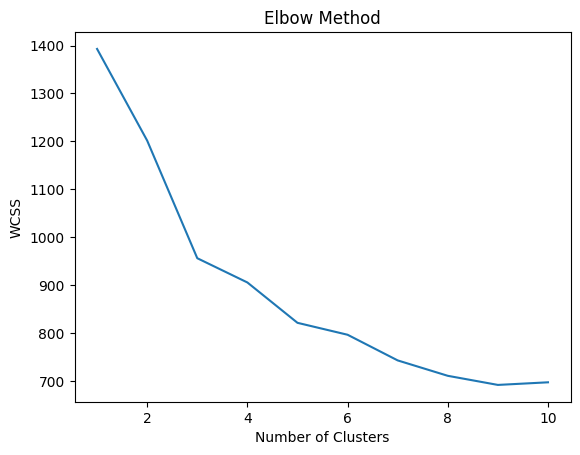

In [19]:
# Determine the optimal number of clusters using the Elbow method - KMedoids
wcss = []
for i in range(1, 11):
    km = KMedoids(n_clusters=i, random_state=42)
    km.fit(results_transformed_scaled)
    wcss.append(km.inertia_)

# Plot the Elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

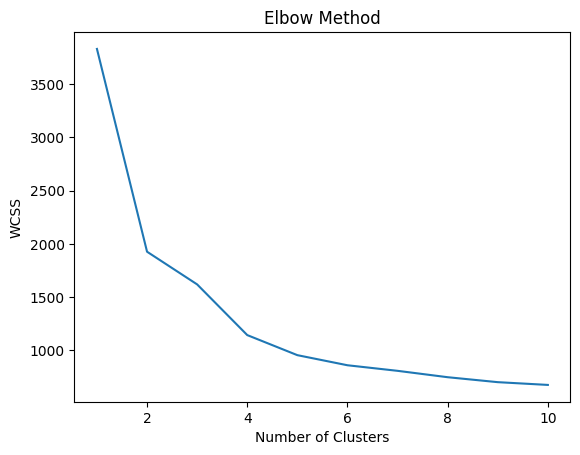

In [20]:
# Determine the optimal number of clusters using the Elbow method - KMeans
wcss = []
for i in range(1, 11):
    km2 = KMeans(n_clusters=i, random_state=42)
    km2.fit(results_transformed_scaled)
    wcss.append(km2.inertia_)

# Plot the Elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [21]:
km = KMedoids(4, method='pam')
c = km.fit(results_transformed_scaled)
print("Loss is:", c.inertia_)

Loss is: 868.793654965851


In [22]:
km2 = KMeans(4)
c2 = km2.fit(results_transformed_scaled)
print("Loss is:", c2.inertia_)

Loss is: 1226.769715879939


In [23]:
results['cluster'] = km.labels_
results.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster
COMPANY_ID,,,,,,
3794,160,28,3.000000,12893.030302,0.428571,1
1046,342,69,0.444444,239.772791,0.181818,2
1128,256,5,1.500000,26619.050786,0.000000,2
4080,85,85,1.000000,4093.598732,0.000000,2
3650,217,8,2.714286,22067.465831,0.285714,1


In [24]:
results['cluster_kmeans'] = km2.labels_
results.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans
COMPANY_ID,,,,,,,
3794,160,28,3.000000,12893.030302,0.428571,1,1
1046,342,69,0.444444,239.772791,0.181818,2,2
1128,256,5,1.500000,26619.050786,0.000000,2,0
4080,85,85,1.000000,4093.598732,0.000000,2,2
3650,217,8,2.714286,22067.465831,0.285714,1,0


In [25]:
# Save model

with open('kmedoids_model.pkl', 'wb') as f:
    pickle.dump((km, km.labels_), f)

In [26]:
# Save model

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump((km2, km2.labels_), f)

In [27]:
# Load model
with open('kmedoids_model.pkl', 'rb') as f:
    km, labels = pickle.load(f)

# new_data_labels = km.predict(new_data)

In [28]:
# Load model
with open('kmeans_model.pkl', 'rb') as f:
    km2, labels2 = pickle.load(f)

# new_data_labels = km2.predict(new_data)

In [29]:
# Sample New Data

# new_data_label = pd.DataFrame()
# new_data_label['cluster'] = pd.DataFrame(km.predict(results_transformed_scaled.drop(columns='cluster')))
# new_data_label.index = results_transformed_scaled.index
# new_data_label = new_data_label.reset_index()
# new_data_label.head()

In [30]:
# Export to SQL for EDA

cursor = conn.cursor()
cursor.execute("""
DROP TABLE IF EXISTS DEV.SBOX_SHILTON.TEST_CLUSTERING_RESULTS;
""")

# Commit the changes
conn.commit()

df_export_cluster = pd.DataFrame(results[['cluster', 'cluster_kmeans']])
df_export_cluster = df_export_cluster.reset_index()
df_export_cluster.head()

df_export_cluster.columns = df_export_cluster.columns.str.upper()

write_pandas(
    conn,
    df_export_cluster,
    table_name='TEST_CLUSTERING_RESULTS',
    database='DEV',
    schema='SBOX_SHILTON',
    auto_create_table=True)

(True,
 1,
 693,
 [('nzugpngwsn/file0.txt', 'LOADED', 693, 693, 1, 0, None, None, None, None)])

In [31]:
results.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans
COMPANY_ID,,,,,,,
3794,160,28,3.000000,12893.030302,0.428571,1,1
1046,342,69,0.444444,239.772791,0.181818,2,2
1128,256,5,1.500000,26619.050786,0.000000,2,0
4080,85,85,1.000000,4093.598732,0.000000,2,2
3650,217,8,2.714286,22067.465831,0.285714,1,0


In [32]:
pd.set_option('display.max_rows', None)  # Display all rows
pd.set_option('display.max_columns', None)  # Display all columns   

pd.set_option('display.max_colwidth', None)

# Group the data by the cluster label and calculate summary statistics
summary_stats = results.groupby('cluster').agg(['count', 'mean', 'median', 'std', 'min', 'max'])

# Print the summary statistics for each cluster
summary_stats

DAYS_SINCE_FIRST_TX                                          \
                      count        mean median         std min  max   
cluster                                                               
0                       141  260.290780  340.0  124.337245   4  366   
1                        99  240.252525  270.0  118.395941   6  366   
2                       402  228.029851  266.0  126.081710   1  365   
3                        51  210.921569  194.0  118.191344  13  365   

        DAYS_SINCE_LAST_TX                                        \
                     count       mean median        std min  max   
cluster                                                            
0                      141   6.872340    4.0  11.416686   1   82   
1                       99  14.919192    8.0  16.409104   1   91   
2                      402  34.818408   26.0  35.750094   1  330   
3                       51  14.411765   12.0  14.384959   1   71   

        AVG_MONTHLY_PAYMENT_COUNT                                            \
                            count       mean    median        std       min   
cluster                                                                       
0                             141  11.922368  7.000000  15.896297  1.818182   
1                              99   2.745052  1.818182   2.934037  0.363636   
2                             402   1.610495  1.272727   1.031142  0.181818   
3                              51   2.469381  1.500000   2.817540  0.555556   

                   AVG_MONTHLY_PAYMENTS                              \
               max                count          mean        median   
cluster                                                               
0        94.000000                  141  37153.416172  23147.241497   
1        20.818182                   99  14361.040403   8514.870710   
2        10.200000                  402   8517.338843   4660.344838   
3        17.400000                   51  11928.791847   8266.342000   

                                                   \
                  std          min            max   
cluster                                             
0        65025.968756  2304.096327  624179.671617   
1        17746.591022   351.888320  111234.863218   
2        12674.340646     7.583800  109965.100000   
3        12591.410269   568.785000   58448.346600   

        PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING                      \
                                           count      mean    median   
cluster                                                                
0                                            141  0.018299  0.000000   
1                                             99  0.392591  0.363636   
2                                            402  0.014867  0.000000   
3                                             51  0.908562  1.000000   

                                      cluster_kmeans                   \
              std       min       max          count      mean median   
cluster                                                                 
0        0.039436  0.000000  0.187500            141  1.893617    3.0   
1        0.129140  0.176471  0.666667             99  0.777778    1.0   
2        0.042413  0.000000  0.214286            402  0.920398    0.0   
3        0.116423  0.666667  1.000000             51  1.000000    1.0   

                           
              std min max  
cluster                    
0        1.452594   0   3  
1        0.827531   0   3  
2        0.998069   0   2  
3        0.000000   1   1

In [33]:
# Group the data by the cluster label and calculate summary statistics
summary_stats2 = results.groupby('cluster_kmeans').agg(['count', 'mean', 'median', 'std', 'min', 'max'])

# Print the summary statistics for each cluster
summary_stats2

DAYS_SINCE_FIRST_TX                                          \
                             count        mean median         std min  max   
cluster_kmeans                                                               
0                              310  237.258065  275.5  123.779025   1  365   
1                               96  228.135417  241.5  119.639953  13  366   
2                              192  220.619792  258.0  124.723343   1  365   
3                               95  264.221053  357.0  128.862798  21  366   

               DAYS_SINCE_LAST_TX                                        \
                            count       mean median        std min  max   
cluster_kmeans                                                            
0                             310  18.687097   12.0  19.316194   1   85   
1                              96  14.895833    9.5  15.471862   1   91   
2                             192  49.906250   42.0  42.519371   1  330   
3                              95   3.926316    1.0   4.079638   1   19   

               AVG_MONTHLY_PAYMENT_COUNT                               \
                                   count       mean median        std   
cluster_kmeans                                                          
0                                    310   2.294550    2.0   1.215961   
1                                     96   2.372438    1.5   2.335417   
2                                    192   1.204856    1.0   0.954300   
3                                     95  16.376572   10.5  17.896641   

                               AVG_MONTHLY_PAYMENTS                \
                     min   max                count          mean   
cluster_kmeans                                                      
0               0.181818   7.0                  310  17308.060082   
1               0.555556  17.4                   96  12413.979059   
2               0.200000  10.2                  192   2379.198342   
3               4.545455  94.0                   95  38722.806133   

                                                                        \
                      median           std          min            max   
cluster_kmeans                                                           
0               10715.475400  25842.842855  1190.732438  352014.716667   
1                7440.252455  14346.056751   568.785000   82420.738400   
2                1464.786232   2297.011403     7.583800   11750.332136   
3               22138.242186  70599.975864  2318.852334  624179.671617   

               PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING                      \
                                                  count      mean    median   
cluster_kmeans                                                                
0                                                   310  0.056726  0.000000   
1                                                    96  0.724737  0.714286   
2                                                   192  0.017887  0.000000   
3                                                    95  0.033325  0.000000   

                                        cluster                             \
                     std  min       max   count      mean median       std   
cluster_kmeans                                                               
0               0.100285  0.0  0.384615     310  1.532258    2.0  0.765725   
1               0.219235  0.4  1.000000      96  2.062500    3.0  1.003284   
2               0.066226  0.0  0.333333     192  1.963542    2.0  0.187918   
3               0.082929  0.0  0.415929      95  0.063158    0.0  0.244537   

                        
               min max  
cluster_kmeans          
0                0   2  
1                1   3  
2                1   2  
3                0   1

In [34]:
results_transformed_scaled['cluster'] = km.labels_
results_transformed_scaled['cluster_kmeans'] = km2.labels_
results_transformed_scaled.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans
COMPANY_ID,,,,,,,
3794,0.360019,0.412930,0.461336,0.337364,3.000000,1,1
1046,-0.443687,0.912593,-0.880468,-1.839111,1.272727,2,2
1128,0.082911,-0.480440,-0.157819,0.733711,0.000000,2,0
4080,0.504786,1.029316,-0.451775,-0.289824,0.000000,2,2
3650,0.213941,-0.250531,0.363710,0.631185,2.000000,1,0


In [35]:
results_transformed_scaled_hvc = results_transformed_scaled[results_transformed_scaled['cluster_kmeans']==2]

results_hvc = results[results['cluster_kmeans']==2]

results_hvc.head()

,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans
COMPANY_ID,,,,,,,
1046,342,69,0.444444,239.772791,0.181818,2,2
4080,85,85,1.000000,4093.598732,0.000000,2,2
2772,357,70,0.666667,1538.577750,0.000000,2,2
4157,61,61,1.000000,910.056000,0.000000,2,2
2629,365,35,0.800000,3208.233309,0.000000,2,2


In [36]:
len(results_transformed_scaled_hvc)

192

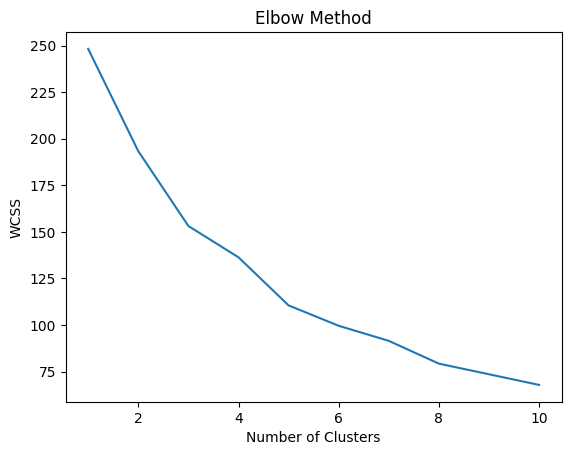

In [37]:
# Determine the optimal number of clusters using the Elbow method - KMeans - HVC Only
wcss = []
for i in range(1, 11):
    km_hvc2 = KMeans(n_clusters=i, random_state=42)
    km_hvc2.fit(results_transformed_scaled_hvc)
    wcss.append(km_hvc2.inertia_)

# Plot the Elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [38]:
km_hvc2 = KMeans(3)
c_hvc = km_hvc2.fit(results_transformed_scaled_hvc)
print("Loss is:", c_hvc.inertia_)

Loss is: 165.03587314412857


In [131]:
results_hvc['cluster_kmeans_hvconly'] = km_hvc2.labels_
results_hvc.head()

/var/folders/sp/wnd46psj0r5_ys790_zv7xgm0000gr/T/ipykernel_1716/2766749247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_hvc['cluster_kmeans_hvconly'] = km_hvc2.labels_


,DAYS_SINCE_FIRST_TX,DAYS_SINCE_LAST_TX,AVG_MONTHLY_PAYMENT_COUNT,AVG_MONTHLY_PAYMENTS,PAYMENT_SCHEDULE_ID_PROPORTION_RECURRING,cluster,cluster_kmeans,cluster_kmeans_hvconly
COMPANY_ID,,,,,,,,
1965,363,20,9.454545,665145.299181,0.000000,1,2,2
2779,355,3,20.000000,33967.003224,0.006061,1,2,0
2996,331,3,5.300000,14099.659143,0.000000,1,2,2
3863,109,2,30.666667,72103.248989,0.350000,1,2,0
3440,249,2,6.750000,77861.926625,0.000000,1,2,2


In [133]:
# Export to SQL for EDA

cursor = conn.cursor()
cursor.execute("""
DROP TABLE IF EXISTS DEV.SBOX_SHILTON.TEST_CLUSTERING_RESULTS_HVCONLY;
""")

# Commit the changes
conn.commit()

df_export_cluster = pd.DataFrame(results_hvc[['cluster_kmeans_hvconly']])
df_export_cluster = df_export_cluster.reset_index()

df_export_cluster.columns = df_export_cluster.columns.str.upper()

write_pandas(
    conn,
    df_export_cluster,
    table_name='TEST_CLUSTERING_RESULTS_HVCONLY',
    database='DEV',
    schema='SBOX_SHILTON',
    auto_create_table=True)

(True,
 1,
 180,
 [('esoaoxtwzu/file0.txt', 'LOADED', 180, 180, 1, 0, None, None, None, None)])